# Module 3 · Session 1 — Lab Notebook
## GPT Architecture & Training Pipeline — "The Model Autopsy"

**Course:** Generative & Agentic AI Systems
**Time:** ~45 minutes (in-session) · seeds this session's assignment

---

### What you'll do
| Part | What | Time |
|---|---|---|
| 1 | Architecture X-ray — map GPT-2's module tree to the anatomy slide | 10 min |
| 2 | Parameter census — count params by component, verify weight tying | 15 min |
| 3 | KV-cache benchmark — time generation with cache on vs off | 15 min |
| 4 | Dimension map — chart what actually changes between model sizes | 5 min |

### Requirements
- Python 3.10+ (course standard: 3.12), **CPU only**
- GPT-2 (~500 MB, likely cached from last session) + DistilGPT-2 (~350 MB, fetched in setup)
- For Part 3 timing: plug in your laptop and disable aggressive battery-saver for cleaner numbers

In [1]:
# Setup — run this cell FIRST (before the break, ideally)
%pip install -q torch transformers matplotlib numpy

import time
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import GPT2LMHeadModel, GPT2Tokenizer, AutoModelForCausalLM, AutoTokenizer

torch.manual_seed(42)

tok = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

distil = AutoModelForCausalLM.from_pretrained("distilgpt2")
distil.eval()

print("Setup OK — GPT-2 and DistilGPT-2 loaded")


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 2931.83it/s]
C:\Users\LENOVO\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--distilgpt2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate De

Setup OK — GPT-2 and DistilGPT-2 loaded


---
## Part 1 — Architecture X-ray (10 min)

Time to see the anatomy slide in real code. Every named component below should be familiar:
`wte` (token embeddings) → `wpe` (position embeddings) → `h[0..N]` (Transformer blocks) → `ln_f` (final LayerNorm) → `lm_head` (output projection).

In [2]:
# The configuration — the "spec sheet" of the architecture
cfg = model.config
print(f"Vocabulary size    : {cfg.vocab_size:,}")
print(f"Hidden size (width): {cfg.n_embd}")
print(f"Layers (depth)     : {cfg.n_layer}")
print(f"Attention heads    : {cfg.n_head}")
print(f"Context window     : {cfg.n_positions}")
print(f"FFN inner size     : {cfg.n_embd * 4}   # GPT-2 uses 4× hidden, the classic ratio")

Vocabulary size    : 50,257
Hidden size (width): 768
Layers (depth)     : 12
Attention heads    : 12
Context window     : 1024
FFN inner size     : 3072   # GPT-2 uses 4× hidden, the classic ratio


In [3]:
# The module tree — the anatomy slide, printed by PyTorch
# (We show one block; all 12 are identical in structure.)
print(model.transformer.wte, " ← token embedding table")
print(model.transformer.wpe, " ← position embedding table")
print("--- one Transformer block (of", cfg.n_layer, ") ---")
print(model.transformer.h[0])
print("--- after the stack ---")
print(model.transformer.ln_f, " ← final LayerNorm")
print(model.lm_head, " ← output projection to logits")

Embedding(50257, 768)  ← token embedding table
Embedding(1024, 768)  ← position embedding table
--- one Transformer block (of 12 ) ---
GPT2Block(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (attn): GPT2Attention(
    (c_attn): Conv1D(nf=2304, nx=768)
    (c_proj): Conv1D(nf=768, nx=768)
    (attn_dropout): Dropout(p=0.1, inplace=False)
    (resid_dropout): Dropout(p=0.1, inplace=False)
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): GPT2MLP(
    (c_fc): Conv1D(nf=3072, nx=768)
    (c_proj): Conv1D(nf=768, nx=3072)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.1, inplace=False)
  )
)
--- after the stack ---
LayerNorm((768,), eps=1e-05, elementwise_affine=True, bias=True)  ← final LayerNorm
Linear(in_features=768, out_features=50257, bias=False)  ← output projection to logits


**Observe (map to the anatomy slide):**
- `attn` inside each block holds the masked self-attention (`c_attn` computes Q, K, V together — its output dim is 3 × 768 = 2304).
- `mlp` is the feed-forward network: 768 → 3072 → 768.
- `lm_head` maps 768 dims back to 50,257 vocab logits — the tensor your sampling code consumed last session.

**✏️ Exercise 1.1** — From the config alone, predict: (a) the shape of one attention layer's `c_attn` weight, and (b) the shape of `mlp.c_fc`. Then print both and check yourself.

In [4]:
# ✏️ Exercise 1.1 — your predictions as comments, then verify:
# (a) c_attn weight shape prediction: ...
# (b) mlp.c_fc weight shape prediction: ...
print("c_attn :", tuple(model.transformer.h[0].attn.c_attn.weight.shape))
print("mlp.c_fc:", tuple(model.transformer.h[0].mlp.c_fc.weight.shape))

c_attn : (768, 2304)
mlp.c_fc: (768, 3072)


---
## Part 2 — Parameter Census (15 min)

The slides claimed: **FFN layers dominate the block budget (~2× attention)** and **`lm_head` is the same tensor as `wte`** (weight tying). Claims are cheap — let's count.

> **Predict before you run:** write down your guess for the attention : FFN : embeddings split of GPT-2's 124M parameters.

In [5]:
def census(m):
    """Count parameters by component for a GPT-2-family model."""
    counts = {"embeddings (wte+wpe)": 0, "attention": 0, "ffn (mlp)": 0, "layernorms": 0, "lm_head (tied)": 0}
    for name, p in m.named_parameters():
        n = p.numel()
        if "wte" in name or "wpe" in name:
            counts["embeddings (wte+wpe)"] += n
        elif ".attn." in name:
            counts["attention"] += n
        elif ".mlp." in name:
            counts["ffn (mlp)"] += n
        elif "ln" in name:
            counts["layernorms"] += n
    total = sum(p.numel() for p in m.parameters())
    return counts, total

counts, total = census(model)
print(f"{'Component':<24} {'Params':>14} {'Share':>8}")
for k, v in counts.items():
    print(f"{k:<24} {v:>14,} {v/total:>7.1%}")
print("-" * 48)
print(f"{'TOTAL':<24} {total:>14,}")
print(f"\nFFN / attention ratio: {counts['ffn (mlp)']/counts['attention']:.2f}×")

Component                        Params    Share
embeddings (wte+wpe)         39,383,808   31.6%
attention                    28,348,416   22.8%
ffn (mlp)                    56,669,184   45.5%
layernorms                       38,400    0.0%
lm_head (tied)                        0    0.0%
------------------------------------------------
TOTAL                       124,439,808

FFN / attention ratio: 2.00×


In [6]:
# Weight tying — not a copy, the SAME tensor
wte = model.transformer.wte.weight
head = model.lm_head.weight
print("Same shape?          ", wte.shape == head.shape)
print("Same values?         ", torch.equal(wte, head))
print("Same storage object? ", wte.data_ptr() == head.data_ptr(), "  ← the decisive check")

Same shape?           True
Same values?          True
Same storage object?  True   ← the decisive check


> **Checkpoint 2:** The census should show FFN ≈ 2× attention per-block (the 4× inner dim does the heavy lifting), with embeddings a big fixed cost at this small scale (~30%!). And `data_ptr()` proves `lm_head` isn't a duplicate — it's literally the `wte` table transposed at use. One table maps tokens in **and** out.

**✏️ Exercise 2.1** — Run `census(distil)` and compare with GPT-2. DistilGPT-2 halves the layers (6 vs 12) but keeps width. Which component shares change, and which stay ~fixed? Why does the embedding share *grow* in the smaller model?

In [7]:
# ✏️ Exercise 2.1 — your comparison here
d_counts, d_total = census(distil)
print(f"DistilGPT-2 total: {d_total:,}   vs GPT-2: {total:,}")
for k in counts:
    print(f"{k:<24} gpt2 {counts[k]/total:>6.1%}   distil {d_counts[k]/d_total:>6.1%}")
# Your explanation as a comment:
# ...

DistilGPT-2 total: 81,912,576   vs GPT-2: 124,439,808
embeddings (wte+wpe)     gpt2  31.6%   distil  48.1%
attention                gpt2  22.8%   distil  17.3%
ffn (mlp)                gpt2  45.5%   distil  34.6%
layernorms               gpt2   0.0%   distil   0.0%
lm_head (tied)           gpt2   0.0%   distil   0.0%


---
## Part 3 — KV-Cache Benchmark (15 min)

The slides claimed the cache turns re-computing the whole sequence into processing **only the newest token** — an *exact* optimization, legal because of the causal mask. Let's measure what that buys.

In [8]:
def time_generation(m, n_new_tokens, use_cache, prompt="The history of artificial intelligence", runs=3):
    ids = tok.encode(prompt, return_tensors="pt")
    times = []
    for _ in range(runs):
        t0 = time.perf_counter()
        with torch.no_grad():
            m.generate(ids, max_new_tokens=n_new_tokens, do_sample=False,
                       use_cache=use_cache, pad_token_id=tok.eos_token_id)
        times.append(time.perf_counter() - t0)
    return min(times)   # min over runs = least noisy estimate

lengths = [10, 25, 50, 100]
with_cache, without_cache = [], []
for n in lengths:
    tc = time_generation(model, n, use_cache=True)
    tn = time_generation(model, n, use_cache=False)
    with_cache.append(tc); without_cache.append(tn)
    print(f"{n:>4} tokens:  cache ON {tc:5.2f}s   cache OFF {tn:5.2f}s   speedup {tn/tc:4.1f}×")

  10 tokens:  cache ON  0.37s   cache OFF  0.50s   speedup  1.3×
  25 tokens:  cache ON  0.90s   cache OFF  1.43s   speedup  1.6×
  50 tokens:  cache ON  1.78s   cache OFF  3.23s   speedup  1.8×
 100 tokens:  cache ON  3.60s   cache OFF  8.09s   speedup  2.2×


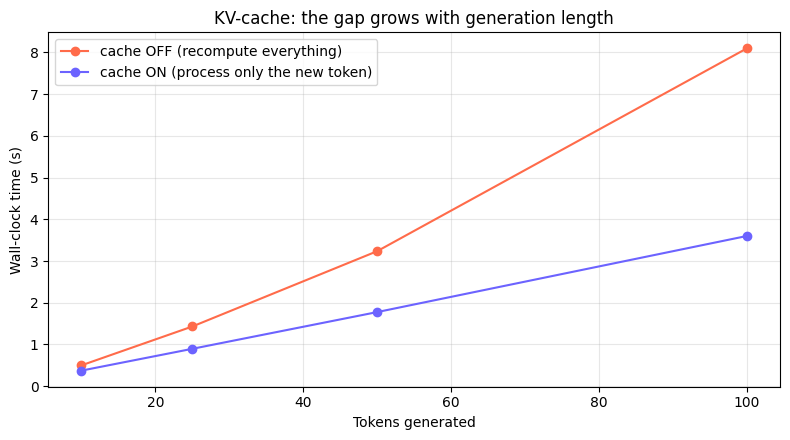

In [9]:
# 📊 The chart — this is the screenshot Slide 20's placeholder asks for
plt.figure(figsize=(8, 4.5))
plt.plot(lengths, without_cache, "o-", color="#FF6B4A", label="cache OFF (recompute everything)")
plt.plot(lengths, with_cache, "o-", color="#6C63FF", label="cache ON (process only the new token)")
plt.xlabel("Tokens generated"); plt.ylabel("Wall-clock time (s)")
plt.title("KV-cache: the gap grows with generation length")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

> **Checkpoint 3:** The gap should *widen* as length grows — without the cache, step *t* pays for all *t−1* previous tokens again. And because the optimization is exact (greedy decoding here), you can verify both settings produce **identical text**.

**✏️ Exercise 3.1** — Prove exactness: generate 30 tokens greedily with `use_cache=True` and `use_cache=False` and assert the outputs are token-identical.

**✏️ Exercise 3.2** — Estimate the cache's memory price for GPT-2 at 1,000 tokens of context: `2 (K and V) × n_layer × n_head × head_dim × seq_len × 4 bytes (fp32)`. Express it in MB. This is the "speed for memory" trade from the slides made numeric.

In [ ]:
# ✏️ Exercises 3.1 & 3.2 — your work here
# 3.1:
# out_a = ...; out_b = ...; assert torch.equal(out_a, out_b)
# 3.2:
# cache_bytes = 2 * cfg.n_layer * cfg.n_head * (cfg.n_embd // cfg.n_head) * 1000 * 4
# print(f"{cache_bytes/1e6:.1f} MB")

---
## Part 4 — Dimension Map (5 min)

What does "a bigger model" actually mean? Fill the comparison — it seeds your assignment directly.

In [10]:
def spec_row(name, m):
    c = m.config
    total = sum(p.numel() for p in m.parameters())
    return [name, c.n_layer, c.n_embd, c.n_head, c.n_positions, f"{total/1e6:.0f}M"]

import pandas as pd
rows = [spec_row("distilgpt2", distil), spec_row("gpt2", model)]
df = pd.DataFrame(rows, columns=["model", "layers", "width", "heads", "context", "params"])
print(df.to_string(index=False))

# Reference points to extend the table by hand (from published GPT-2 specs):
#   gpt2-medium: 24 layers, 1024 width, 16 heads → ~355M
#   gpt2-large : 36 layers, 1280 width, 20 heads → ~774M
#   gpt2-xl    : 48 layers, 1600 width, 25 heads → ~1.5B

     model  layers  width  heads  context params
distilgpt2       6    768     12     1024    82M
      gpt2      12    768     12     1024   124M


**✏️ Exercise 4.1** — Using the census logic, explain in 2–3 sentences *where* the extra parameters go when moving gpt2 → gpt2-medium (hint: blocks scale with `layers × width²`; embeddings scale with `vocab × width`). Which grows faster, and what does that mean for the embedding share at large scale?

---
## 🏆 Challenges (optional, ranked)

1. **Memory footprint audit (⭐⭐)** — Compute each model's weight memory at fp32 and fp16, then verify against `sum(p.numel() * p.element_size() ...)`. How much RAM would gpt2-xl (1.5B) need at each precision?
2. **Scaling extrapolation (⭐⭐)** — Write a function `predict_params(layers, width, vocab=50257, ctx=1024)` from the component formulas, and validate it against both loaded models to within 2%. Then predict gpt2-medium and check against the reference (~355M).
3. **The logit lens (⭐⭐⭐)** — After each layer, apply `ln_f` + `lm_head` to the hidden state of the last position and print the top-1 token per layer for a prompt like `"The capital of France is"`. Watch the prediction *sharpen with depth* — the residual stream refining its guess, layer by layer.


In [11]:
# 🏆 Challenge workspace — starter for the logit lens (Challenge 3):
def logit_lens(prompt):
    ids = tok.encode(prompt, return_tensors="pt")
    with torch.no_grad():
        out = model(ids, output_hidden_states=True)
    for i, h in enumerate(out.hidden_states):        # hidden_states[0] = embeddings, then one per layer
        logits = model.lm_head(model.transformer.ln_f(h[0, -1]))
        top = tok.decode([int(logits.argmax())])
        print(f"after layer {i:>2}: {top!r}")

logit_lens("The capital of France is")

after layer  0: ' destro'
after layer  1: ' not'
after layer  2: ' now'
after layer  3: ' now'
after layer  4: ' now'
after layer  5: ' now'
after layer  6: ' now'
after layer  7: ' now'
after layer  8: ' now'
after layer  9: ' now'
after layer 10: ' France'
after layer 11: ' France'
after layer 12: ' the'


---
## Summary

| Concept | What you did |
|---|---|
| Architecture | Mapped GPT-2's real module tree onto the anatomy slide — wte/wpe → blocks → ln_f → lm_head |
| Parameter budget | Counted the census: FFN ≈ 2× attention per block; embeddings a large fixed cost at small scale |
| Weight tying | Proved wte and lm_head share storage with a `data_ptr()` identity check |
| KV-cache | Measured the widening speedup and its exactness; priced its memory cost |
| Scale | Charted what "bigger" means dimensionally — depth, width, heads — and where new parameters go |

**Next:** the assignment notebook ("Model Selection Autopsy") turns this dissection into a deployment recommendation.

*Module 3 · Session 1 — Generative & Agentic AI Systems*